# Frontal Beta Step-by-Step Test

This notebook tests the Frontal Beta pipeline in `ppg_eeg.eeg` on one existing EEG file in this repo.

Functions tested:
- `preprocess_eeg`
- `_beta_power_per_channel` (internal helper)
- `frontal_beta` (linear and log-transformed)
- `frontal_beta_value` (convenience wrapper)
- `plot_frontal_beta`

Frontal Beta here is computed as beta-band power over frontal channels, averaged across channels, with optional natural-log transform.

In [1]:
%matplotlib inline

from pathlib import Path
import sys
import importlib
import numpy as np
import mne
import matplotlib.pyplot as plt

# Make imports robust regardless of notebook working directory.
repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ppg_eeg").is_dir():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root containing 'ppg_eeg' directory.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo root:", repo_root)

# Force-refresh module in case the kernel cached an older version.
import ppg_eeg.eeg as eeg_mod
eeg_mod = importlib.reload(eeg_mod)
print("Loaded eeg module from:", eeg_mod.__file__)

required_symbols = [
    "FRONTAL_BETA_CHANNELS_DEFAULT",
    "preprocess_eeg",
    "_beta_power_per_channel",
    "frontal_beta",
    "frontal_beta_value",
    "plot_frontal_beta",
]
missing_symbols = [name for name in required_symbols if not hasattr(eeg_mod, name)]
if missing_symbols:
    raise RuntimeError(
        "Current kernel loaded a ppg_eeg.eeg missing required symbols: "
        + ", ".join(missing_symbols)
        + ". Restart kernel and re-run from the first cell."
    )

FRONTAL_BETA_CHANNELS_DEFAULT = eeg_mod.FRONTAL_BETA_CHANNELS_DEFAULT
preprocess_eeg = eeg_mod.preprocess_eeg
_beta_power_per_channel = eeg_mod._beta_power_per_channel
frontal_beta = eeg_mod.frontal_beta
frontal_beta_value = eeg_mod.frontal_beta_value
plot_frontal_beta = eeg_mod.plot_frontal_beta


Using repo root: /Users/sarabonyadian/Documents/HIIT/ppg-eeg
Loaded eeg module from: /Users/sarabonyadian/Documents/HIIT/ppg-eeg/ppg_eeg/eeg.py


In [2]:
# Choose one EEG file from a non-HIIT dataset (prefer ds006848)
raw_data_dir = repo_root / "data" / "raw"
preferred_dataset_dir = raw_data_dir / "ds006848"

if preferred_dataset_dir.is_dir():
    candidate_files = sorted(preferred_dataset_dir.rglob("*.vhdr"))
    dataset_used = preferred_dataset_dir.name
else:
    # Fallback: any non-HIIT folder under data/raw
    candidate_files = []
    dataset_used = None
    for d in sorted(raw_data_dir.iterdir()):
        if d.is_dir() and d.name.lower() != "hiit":
            files = sorted(d.rglob("*.vhdr"))
            if files:
                candidate_files = files
                dataset_used = d.name
                break

if not candidate_files:
    raise FileNotFoundError(
        f"No BrainVision .vhdr file found in non-HIIT datasets under {raw_data_dir}"
    )

# Prefer rest recordings in ds006848, otherwise first file.
rest_files = [p for p in candidate_files if "task-rest" in p.name]
eeg_vhdr_path = rest_files[0] if rest_files else candidate_files[0]

print("Dataset used:", dataset_used)
print("Selected EEG file:", eeg_vhdr_path)


Dataset used: ds006848
Selected EEG file: /Users/sarabonyadian/Documents/HIIT/ppg-eeg/data/raw/ds006848/sub-001/eeg/sub-001_task-rest_eeg.vhdr


In [3]:
# Load EEG and keep EEG channels only
raw = mne.io.read_raw_brainvision(eeg_vhdr_path, preload=True, verbose="ERROR")
raw.pick_types(eeg=True)

print(raw)
print("Sampling frequency:", raw.info["sfreq"])
print("Number of EEG channels:", len(raw.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawBrainVision | sub-001_task-rest_eeg.eeg, 64 x 732280 (732.3 s), ~357.6 MiB, data loaded>
Sampling frequency: 1000.0
Number of EEG channels: 64


In [5]:
# Step 0: preprocess (band-pass, drop bad channels, common-average reference)
pre = preprocess_eeg(raw)
raw_pp = pre.raw

print("Bad channels dropped:", pre.bad_channels)
print("Remaining channels:", len(raw_pp.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Bad channels dropped: ['ECG']
Remaining channels: 63


In [6]:
# Inspect which default frontal-beta channels are usable in this file
available = [ch for ch in FRONTAL_BETA_CHANNELS_DEFAULT if ch in raw_pp.ch_names]
missing = [ch for ch in FRONTAL_BETA_CHANNELS_DEFAULT if ch not in raw_pp.ch_names]

print("Default frontal-beta channels:", FRONTAL_BETA_CHANNELS_DEFAULT)
print("Available channels in this file:", available)
print("Missing channels in this file:", missing)


Default frontal-beta channels: ['F3', 'F4', 'F7', 'F8', 'Fz', 'FCz']
Available channels in this file: ['F3', 'F4', 'F7', 'F8', 'Fz']
Missing channels in this file: ['FCz']


In [7]:
# Step 1: internal helper _beta_power_per_channel
beta_per_ch = _beta_power_per_channel(
    raw_pp,
    FRONTAL_BETA_CHANNELS_DEFAULT,
    beta_band=(13.0, 30.0),
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("Per-channel beta power (uV^2):")
for ch in FRONTAL_BETA_CHANNELS_DEFAULT:
    val = beta_per_ch.get(ch)
    if val is None or not np.isfinite(val):
        print(f"  {ch}: NaN")
    else:
        print(f"  {ch}: {val:.6f}")


Per-channel beta power (uV^2):
  F3: 5.055900
  F4: 5.472502
  F7: 5.701411
  F8: 9.056084
  Fz: 6.281584
  FCz: NaN


In [8]:
# Step 2: frontal_beta without log-transform (linear mean beta power)
res_linear = frontal_beta(
    raw_pp,
    channels=FRONTAL_BETA_CHANNELS_DEFAULT,
    beta_band=(13.0, 30.0),
    log_transform=False,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("beta_band_used:", res_linear.beta_band_used)
print("per_channel_power:")
for ch, val in res_linear.per_channel_power.items():
    print(f"  {ch}: {val:.6f}" if np.isfinite(val) else f"  {ch}: NaN")
print("mean_beta_power (uV^2):", res_linear.mean_beta_power)
print("frontal_beta (linear):", res_linear.frontal_beta)
print("missing_channels:", res_linear.missing_channels)


beta_band_used: (13.0, 30.0)
per_channel_power:
  F3: 5.055900
  F4: 5.472502
  F7: 5.701411
  F8: 9.056084
  Fz: 6.281584
  FCz: NaN
mean_beta_power (uV^2): 6.31349626375836
frontal_beta (linear): 6.31349626375836
missing_channels: ['FCz']


In [9]:
# Step 3: frontal_beta with log-transform (recommended scalar)
res_log = frontal_beta(
    raw_pp,
    channels=FRONTAL_BETA_CHANNELS_DEFAULT,
    beta_band=(13.0, 30.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("mean_beta_power (uV^2):", res_log.mean_beta_power)
print("frontal_beta (log):", res_log.frontal_beta)
if np.isfinite(res_log.mean_beta_power) and res_log.mean_beta_power > 0:
    print("Manual ln(mean_beta_power):", np.log(res_log.mean_beta_power))


mean_beta_power (uV^2): 6.31349626375836
frontal_beta (log): 1.8426896061103073
Manual ln(mean_beta_power): 1.8426896061103073


In [10]:
# Step 4: convenience wrapper should match frontal_beta(..., log_transform=True).frontal_beta
fb_wrapper = frontal_beta_value(
    raw_pp,
    channels=FRONTAL_BETA_CHANNELS_DEFAULT,
    beta_band=(13.0, 30.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("frontal_beta_value:", fb_wrapper)
print("frontal_beta(...).frontal_beta:", res_log.frontal_beta)

if np.isfinite(fb_wrapper) and np.isfinite(res_log.frontal_beta):
    print("Abs difference:", abs(fb_wrapper - res_log.frontal_beta))
    assert np.isclose(fb_wrapper, res_log.frontal_beta, atol=1e-12)
    print("OK: wrapper matches frontal_beta output.")
else:
    print("At least one value is NaN; equality check skipped.")


frontal_beta_value: 1.8426896061103073
frontal_beta(...).frontal_beta: 1.8426896061103073
Abs difference: 0.0
OK: wrapper matches frontal_beta output.


plot_frontal_beta -> frontal_beta: 1.8426896061103073
plot_frontal_beta -> mean_beta_power (uV^2): 6.31349626375836
plot_frontal_beta -> missing_channels: ['FCz']


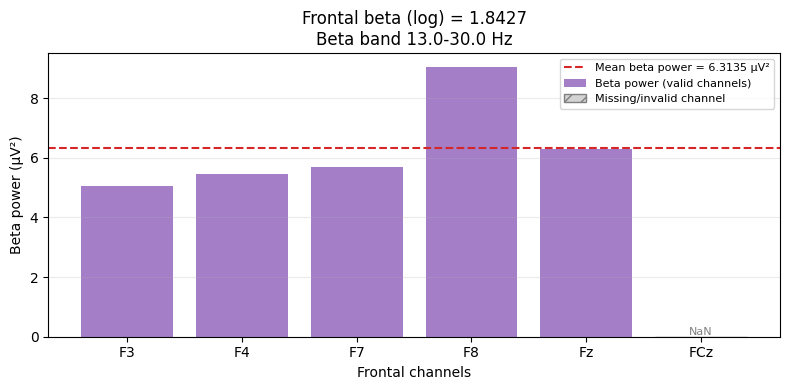

In [11]:
# Step 5: plot_frontal_beta visualization
plot_res = plot_frontal_beta(
    raw_pp,
    channels=FRONTAL_BETA_CHANNELS_DEFAULT,
    beta_band=(13.0, 30.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("plot_frontal_beta -> frontal_beta:", plot_res.result.frontal_beta)
print("plot_frontal_beta -> mean_beta_power (uV^2):", plot_res.result.mean_beta_power)
print("plot_frontal_beta -> missing_channels:", plot_res.result.missing_channels)

plt.show()
